In [43]:
import argparse
import json
import csv
import glob

import os
import sys
sys.path.append("../..")
from pathlib import Path
from tqdm import tqdm
import pandas as pd
import numpy as np

import random

import nibabel as nib

import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
ROOT_DIR = "/bettik/PROJECTS/pr-gin5_aini/fehrdelt/"
SOOP_DIR = f"{ROOT_DIR}datasets/final_soop_dataset_small/"

In [4]:
adc_folder = os.path.join(SOOP_DIR, "adc_registered")
flair_folder = os.path.join(SOOP_DIR, "flair_registered")

masks_acute_folder = os.path.join(SOOP_DIR, "masks_acute_registered")
masks_chronic_folder = os.path.join(SOOP_DIR, "masks_chronic_registered")
masks_combined_folder = os.path.join(SOOP_DIR, "masks_combined_registered")

In [37]:
def scale_intensity_from_histogram_peak(input_image, target_value=1.0):
    # to be used only on mri images with intensities between 0 and 1

    #print(f"max input image value: {np.max(input_image)}")

    hist, bin_edges = np.histogram(input_image.flatten(), bins=100, range=(np.max(input_image)/15.0, np.max(input_image)))

    peak_value = bin_edges[np.argmax(hist)]

    normalized_image = input_image / peak_value * target_value

    return normalized_image

In [ ]:
def analyze_patient(path_adc, path_flair, path_mask_acute, path_mask_chronic):

    # images
    adc_img = nib.load(path_adc)
    adc_data = scale_intensity_from_histogram_peak(adc_img.get_fdata())

    flair_img = nib.load(path_flair)
    flair_data = scale_intensity_from_histogram_peak(flair_img.get_fdata())

    # masks
    if path_mask_acute is not None:
        mask_acute_img = nib.load(path_mask_acute)
        mask_acute_data = mask_acute_img.get_fdata()
        # Get mean intensity for non-zero voxels of acute mask
        acute_mask_indices = mask_acute_data > 0
        
        mean_adc_acute = np.mean(adc_data[acute_mask_indices]) if np.any(acute_mask_indices) else np.nan
        mean_flair_acute = np.mean(flair_data[acute_mask_indices]) if np.any(acute_mask_indices) else np.nan
    else:
        mean_adc_acute = np.nan
        mean_flair_acute = np.nan

    if path_mask_chronic is not None:
        mask_chronic_img = nib.load(path_mask_chronic)
        mask_chronic_data = mask_chronic_img.get_fdata()
        chronic_mask_indices = mask_chronic_data > 0
        
        mean_adc_chronic = np.mean(adc_data[chronic_mask_indices]) if np.any(chronic_mask_indices) else np.nan
        mean_flair_chronic = np.mean(flair_data[chronic_mask_indices]) if np.any(chronic_mask_indices) else np.nan
    else:
        mean_adc_chronic = np.nan
        mean_flair_chronic = np.nan
    
    return mean_adc_acute, mean_flair_acute, mean_adc_chronic, mean_flair_chronic

In [39]:
lesion_stats = pd.DataFrame(columns=["patient_id", "mean_adc_acute", "mean_flair_acute", "mean_adc_chronic", "mean_flair_chronic"])

for file in tqdm(os.listdir(adc_folder)): #TODO the first 50 files only for testing

    patient_id = file.split(".")[0]
    
    path_adc = os.path.join(adc_folder, file)
    path_flair = os.path.join(flair_folder, file)

    path_mask_acute = os.path.join(masks_acute_folder, file)
    path_mask_chronic = os.path.join(masks_chronic_folder, file)
    
    if not os.path.exists(path_flair):
        path_flair = None
    if not os.path.exists(path_mask_chronic):
        path_mask_chronic = None
    if not os.path.exists(path_mask_acute):
        path_mask_acute = None

    if path_mask_acute is None:
        continue  # Skip patients without necessary masks


    
    mean_adc_acute, mean_flair_acute, mean_adc_chronic, mean_flair_chronic = analyze_patient(
        path_adc, path_flair, path_mask_acute, path_mask_chronic
    )


    lesion_stats = pd.concat([lesion_stats, pd.DataFrame([{
        "patient_id": patient_id,
        "mean_adc_acute": mean_adc_acute,
        "mean_flair_acute": mean_flair_acute,
        "mean_adc_chronic": mean_adc_chronic,
        "mean_flair_chronic": mean_flair_chronic
    }])], ignore_index=True)

  0%|                                                                                                                                                                                       | 0/1715 [00:00<?, ?it/s]/tmp/ipykernel_12784/2495338863.py:30: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  lesion_stats = pd.concat([lesion_stats, pd.DataFrame([{
100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1715/1715 [39:57<00:00,  1.40s/it]


In [46]:
lesion_stats.to_csv(f"{ROOT_DIR}AnoDiffExperiments/dataset_preprocessing/soop/lesion_stats.csv", index=False)

after the datafram has been saved, i can add information about lesion size (large, medium or small group)

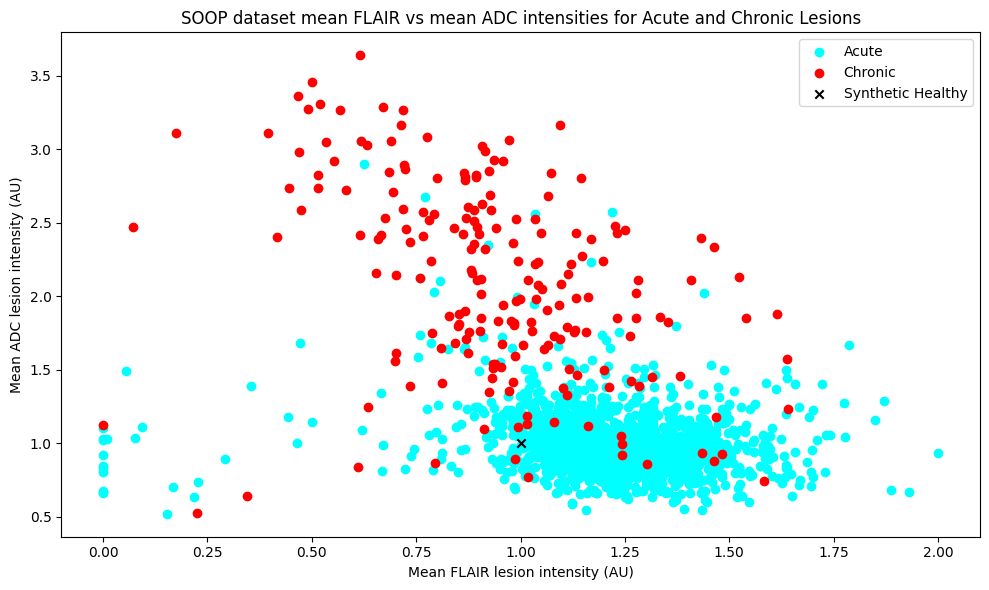

In [58]:
fig, ax = plt.subplots(figsize=(10, 6))

# Scatter plot for acute lesions
ax.scatter(lesion_stats['mean_flair_acute'], lesion_stats['mean_adc_acute'], 
           label='Acute', alpha=1.0, c='cyan')

# Scatter plot for chronic lesions (excluding NaN values)
chronic_mask = lesion_stats['mean_adc_chronic'].notna()
ax.scatter(lesion_stats.loc[chronic_mask, 'mean_flair_chronic'], 
           lesion_stats.loc[chronic_mask, 'mean_adc_chronic'], 
           label='Chronic', alpha=1.0, c='red')

ax.scatter([1.0], [1.0], c='black', label='Synthetic Healthy', marker='x', alpha=1.0)  # Placeholder for healthy

ax.set_xlabel('Mean FLAIR lesion intensity (AU)')
ax.set_ylabel('Mean ADC lesion intensity (AU)')
ax.set_title('SOOP dataset mean FLAIR vs mean ADC intensities for Acute and Chronic Lesions')
ax.legend()
plt.tight_layout()
plt.show()

#### Faire pareil mais avec intensité médiane

#### Mettre des images saines en vert dans le graphique

In [44]:

healthy_adc_folder = f"{ROOT_DIR}datasets/final_adc_dataset_small/"
healthy_adc_files = os.listdir(healthy_adc_folder)
random.shuffle(healthy_adc_files)

healthy_flair_folder = f"{ROOT_DIR}datasets/final_flair_dataset_small/"
healthy_flair_files = os.listdir(healthy_flair_folder)
random.shuffle(healthy_flair_files)